In [10]:
import pandas as pd
%pip install requests
import requests

# Din personlige Client ID fra frost.met.no
client_id = 'fc1b5178-1f3d-4ea7-af3a-c4035ce59dde'

# Endepunkt for observasjoner
endpoint = 'https://frost.met.no/observations/v0.jsonld'

# Parametere for Task 1 (Døgnmiddeltemperatur for Ås i 2025)
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

# Utfør API-kallet (bruker client_id som brukernavn og tomt passord)
r = requests.get(endpoint, parameters, auth=(client_id, ''))
json_data = r.json()

# Sjekk om forespørselen var vellykket (HTTP 200)
if r.status_code == 200:
    data = json_data['data']

    # Pakk ut data til en liste med ordbøker (dictionaries)
    rows = []
    for obs in data:
        time = obs['referenceTime']
        for val in obs['observations']:
            rows.append({'referenceTime': time, 'temperature': val['value']})

    # Gjør om til en pandas DataFrame
    df = pd.DataFrame(rows)
    df['referenceTime'] = pd.to_datetime(df['referenceTime'])

    print("Data ble hentet ut uten feil!")
    print(df.head())
else:
    print(f"Feil oppsto: {r.status_code}")
    print(json_data['error']['reason'])


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\risha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Data ble hentet ut uten feil!
              referenceTime  temperature
0 2025-01-01 00:00:00+00:00         -5.2
1 2025-01-01 00:00:00+00:00         -2.8
2 2025-01-02 00:00:00+00:00        -11.5
3 2025-01-02 00:00:00+00:00         -7.2
4 2025-01-03 00:00:00+00:00         -8.9


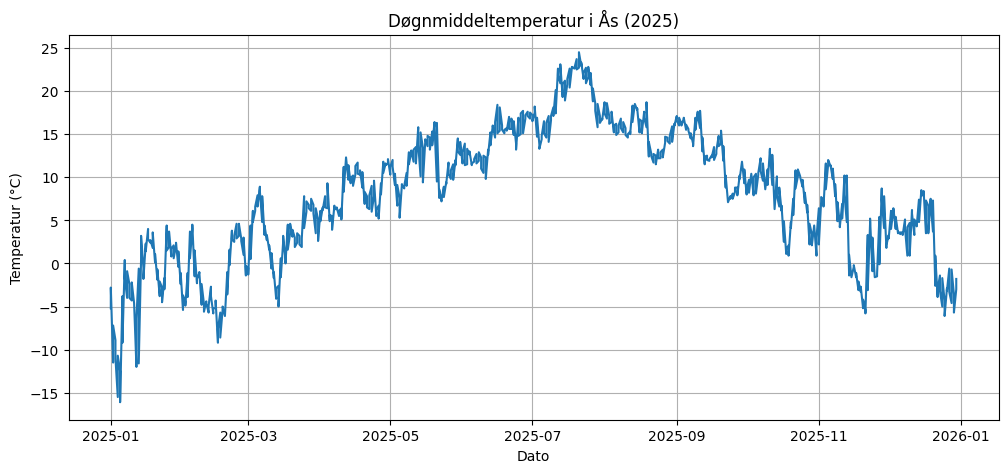

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df['referenceTime'], df['temperature'], color='tab:blue')
plt.title('Døgnmiddeltemperatur i Ås (2025)')
plt.xlabel('Dato')
plt.ylabel('Temperatur (°C)')
plt.grid(True)
plt.show()

In [12]:
stats = df['temperature'].agg(['mean', 'median', 'min', 'max'])
print("Oppsummeringstabell for lufttemperatur i Ås 2025:")
print(stats)

Oppsummeringstabell for lufttemperatur i Ås 2025:
mean       7.903571
median     8.350000
min      -16.100000
max       24.500000
Name: temperature, dtype: float64
